# WhatsApp Group Chat Analysis

This notebook helps you look at your WhatsApp group chat. We will see who talks the most, when people chat, and other simple things. Each step is easy to follow.

In [29]:
import re
import spacy
import pandas as pd
import emoji
from gensim import corpora
from gensim.models import CoherenceModel
from gensim.models.ldamodel import LdaModel
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer


In [30]:
# Download VADER lexicon if not already downloaded
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/madhusudhananjeyaram/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## Data Loading and Preprocessing

First, we'll load our WhatsApp chat file and clean it up. This means getting rid of any messy parts, like emojis, and making sure the data is ready for us to work with.

In [31]:
def load_chat_data(filepath):
    """
    Loads chat data from a text file, skipping bad lines.
    """
    df = pd.read_csv(filepath, header=None, encoding='utf8', on_bad_lines='skip')
    return df

## Exploratory Data Analysis

Let's take a look at our chat data to see who's in the group, how much everyone talks, and what the messages look like. This helps us get a feel for the group before we dive deeper.

In [32]:
def remove_emoji(text):
    return emoji.replace_emoji(text, replace='')

In [33]:
def preprocess_chat_dataframe(df):
    """
    Cleans and structures the chat DataFrame.
    Drops the first row, renames columns, splits chat into time, name, and message.
    Returns the processed DataFrame.
    """
    df = df.drop(0)
    df.columns = ['Date', 'Chat']
    Message = df["Chat"].str.split("-", n=1, expand=True)
    df["Time"] = Message[0]
    Message1 = Message[1].str.split(":", n=1, expand=True)
    df["Name"] = Message1[0]
    df["Chat"] = Message1[1].apply(remove_emoji)
    df = df[["Date", "Time", "Name", "Chat"]]
    return df

## Flirt Prediction Model (TF-IDF)

Here, we'll try to guess if a message is flirty or not using some smart math (TF-IDF) and a simple model. We'll also see how well our model does at this task.

In [34]:
def build_flirt_prediction_model(df, text_column='Chat'):
    """
    Builds a flirt prediction model using TF-IDF vectorization and Naive Bayes classification.
    Assumes df has a 'Chat' column and a binary 'is_flirt' label column (1=flirt, 0=not flirt).
    Returns the trained model and vectorizer.
    """
    # Example: Create dummy labels based on keywords (replace with real labels for production)
    flirt_keywords = [
    # Compliments
    "cute", "beautiful", "pretty", "handsome", "gorgeous", "sweet", "lovely", "adorable",
    "nice smile",

    # Emotional closeness
    "miss you", "thinking of you", "can't stop thinking", "wish you were here",
    "feel close", "you mean a lot", "need you",

    # Attraction hints
    "crush", "i like you", "i like talking to you", "favorite person",
    "i want to see you", "see you again", "let's meet", "date",

    # Romantic tone
    "baby", "babe", "dear", "darling", "love", "my love", "my heart",

    # Playful teasing
    "naughty", "teasing", "you flirt", "don't make me blush",
    "are you trying to impress", "you are trying to flirt",

    # Intimate compliments / signals
    "you make me smile", "you made my day", "you look amazing",
    "you looked good", "talking to you feels", "talking to you is the best",

    # Strong flirting emojis
    "😘", "😍", "😉", "😊", "❤️", "💕", "🥰"
]
    df['is_flirt'] = df[text_column].str.lower().apply(lambda x: int(any(word in x for word in flirt_keywords)))
    
    X = df[text_column].fillna('')
    y = df['is_flirt']
    
    # TF-IDF Vectorization
    vectorizer = TfidfVectorizer()
    X_vec = vectorizer.fit_transform(X)
    
    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)
    
    # Naive Bayes Classifier
    clf = MultinomialNB()
    clf.fit(X_train, y_train)
    
    print("TF-IDF + Naive Bayes Validation Accuracy:", clf.score(X_test, y_test))
    print("Interpretation: This means {:.2f}% of the test messages were correctly classified as flirt or not flirt using TF-IDF + Naive Bayes.".format(clf.score(X_test, y_test)*100))
    return clf, vectorizer

In [35]:
def build_flirt_prediction_model_count(df, text_column='Chat'):
    """
    Builds a flirt prediction model using CountVectorizer and Naive Bayes classification.
    Assumes df has a 'Chat' column and a binary 'is_flirt' label column (1=flirt, 0=not flirt).
    Returns the trained model and vectorizer.
    """
       # Example: Create dummy labels based on keywords (replace with real labels for production)
    flirt_keywords = [
    # Compliments
    "cute", "beautiful", "pretty", "handsome", "gorgeous", "sweet", "lovely", "adorable",
    "nice smile",

    # Emotional closeness
    "miss you", "thinking of you", "can't stop thinking", "wish you were here",
    "feel close", "you mean a lot", "need you",

    # Attraction hints
    "crush", "i like you", "i like talking to you", "favorite person",
    "i want to see you", "see you again", "let's meet", "date",

    # Romantic tone
    "baby", "babe", "dear", "darling", "love", "my love", "my heart",

    # Playful teasing
    "naughty", "teasing", "you flirt", "don't make me blush",
    "are you trying to impress", "you are trying to flirt",

    # Intimate compliments / signals
    "you make me smile", "you made my day", "you look amazing",
    "you looked good", "talking to you feels", "talking to you is the best",

    # Strong flirting emojis
    "😘", "😍", "😉", "😊", "❤️", "💕", "🥰"
]
    df['is_flirt'] = df[text_column].str.lower().apply(lambda x: int(any(word in x for word in flirt_keywords)))
    
    X = df[text_column].fillna('')
    y = df['is_flirt']
    
    # Count Vectorization
    vectorizer = CountVectorizer()
    X_vec = vectorizer.fit_transform(X)
    
    # Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(X_vec, y, test_size=0.2, random_state=42)
    
    # Naive Bayes Classifier
    clf = MultinomialNB()
    clf.fit(X_train, y_train)
    
    print("CountVectorizer + Naive Bayes Validation Accuracy:", clf.score(X_test, y_test))
    print("Interpretation: This means {:.2f}% of the test messages were correctly classified as flirt or not flirt using CountVectorizer + Naive Bayes.".format(clf.score(X_test, y_test)*100))
    return clf, vectorizer

In [36]:
def select_and_apply_best_flirt_model(df, model, tfidf_vectorizer, model_count, count_vectorizer):
    """
    Compares TF-IDF and CountVectorizer models, selects the best, prints summary, and applies to each chat row.
    """
    tfidf_accuracy = model.score(tfidf_vectorizer.transform(df['Chat'].fillna('')), df['is_flirt'])
    count_accuracy = model_count.score(count_vectorizer.transform(df['Chat'].fillna('')), df['is_flirt'])

    if tfidf_accuracy > count_accuracy:
        chosen_model = model
        chosen_vectorizer = tfidf_vectorizer
        chosen_name = "TF-IDF Vectorizer"
        chosen_accuracy = tfidf_accuracy
    else:
        chosen_model = model_count
        chosen_vectorizer = count_vectorizer
        chosen_name = "CountVectorizer"
        chosen_accuracy = count_accuracy

    print(f"Summary: Based on the validation accuracy, the {chosen_name} + Naive Bayes model was chosen for flirt prediction.")
    print(f"Final Validation Accuracy: {chosen_accuracy:.2f}")
    print("This approach is effective when your data is well-labeled and the model achieves high accuracy on unseen messages.")
    print("For a more robust evaluation, consider also checking precision, recall, F1-score, and confusion matrix.")

    # Apply the chosen model to each chat row
    df['isFlirt'] = chosen_model.predict(chosen_vectorizer.transform(df['Chat'].fillna('')))
    print(df[['Chat', 'isFlirt']].head(10))
    if 'is_flirt' in df.columns:
        df = df.drop(columns=['is_flirt'])
    return df, chosen_model, chosen_vectorizer, chosen_name, chosen_accuracy

## Flirt Prediction Model (CountVectorizer)

Now, let's try a different way to look at the words in our messages (CountVectorizer) and see if it helps our model do a better job at spotting flirty messages.

In [37]:
def talkative_stats(df, top_n=3):
    """
    Prints and plots the most and least talkative users in the chat.
    """
    talk_counts = df['Name'].value_counts()
    print("Most Talkative:")
    print(talk_counts.head(top_n))
    print("\nLeast Talkative:")
    print(talk_counts.tail(top_n))
    import matplotlib.pyplot as plt
    talk_counts.plot(kind='bar', figsize=(10,4), title='Messages per User')
    plt.xlabel('User')
    plt.ylabel('Number of Messages')
    plt.show()

## Model Selection and Application

We'll compare both models and pick the one that works best. Then, we'll use it to label all the messages in our chat as flirty or not.

In [38]:
def most_active_day_time(df):
    """
    Prints the most active day and most active time (hour) in the chat.
    """
    # Convert Date and Time columns to datetime if not already
    dt = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
    df['datetime'] = dt

    # Most active day
    most_active_day = df['datetime'].dt.date.value_counts().idxmax()
    print(f"Most Active Day: {most_active_day}")

    # Most active hour
    most_active_hour = df['datetime'].dt.hour.value_counts().idxmax()
    print(f"Most Active Hour: {most_active_hour}:00")

    # Optional: Plot activity by hour
    import matplotlib.pyplot as plt
    df['datetime'].dt.hour.value_counts().sort_index().plot(kind='bar', figsize=(10,4), title='Messages per Hour')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Messages')
    plt.show()

## Talkative and Less Talkative Users

Let's find out who talks the most and who talks the least in our group chat. This will show us who keeps the conversation going and who prefers to stay quiet.

In [39]:
def media_count_per_person(df, media_text="Media omitted"):
    """
    Prints and plots the number of media messages sent by each person.
    """
    # Filter rows where the chat/message indicates media was sent
    media_df = df[df['Chat'].str.contains(media_text, na=False)]
    media_counts = media_df['Name'].value_counts()
    print("Media messages sent by each person:")
    print(media_counts)

    import matplotlib.pyplot as plt
    media_counts.plot(kind='bar', figsize=(8,4), title='Media Messages per User')
    plt.xlabel('User')
    plt.ylabel('Media Messages Sent')
    plt.show()

## Most Active Day and Time

When does our group chat come alive? We'll check which days and times people are most active, so you can see when the group is buzzing.

In [ ]:
def missed_call_stats(df, missed_call_text="Missed voice call"):
    """
    Prints all missed call messages and counts per user.
    """
    missed_calls = df[df['Chat'].str.contains(missed_call_text, na=False)]
    print("All missed call messages:")
    print(missed_calls[['Date', 'Time', 'Name', 'Chat']])
    print("\nMissed call count per user:")
    print(missed_calls['Name'].value_counts())

    import matplotlib.pyplot as plt
    missed_calls['Name'].value_counts().plot(kind='bar', figsize=(8,4), title='Missed Calls per User')
    plt.xlabel('User')
    plt.ylabel('Missed Calls')
    plt.show()

## Media and Missed Call Analysis

Who sends the most photos, videos, or makes calls? Let's count up the media files and missed calls to see who uses these features the most in our group.

In [41]:
lines = load_chat_data('../input/whatsapp_chat.txt')
print(lines.head())  # Show first 5 lines for verification

            0                                                  1
0  01/01/2024                       11:02 - Alex: Weekend plans?
1  01/01/2024                       14:24 - Riya: Weekend plans?
2  01/01/2024   14:47 - Riya: You are kind of my favorite per...
3  01/01/2024                  14:51 - Alex: Did you reach home?
4  01/01/2024          14:55 - John: Missed video call from Riya


In [42]:
df = preprocess_chat_dataframe(lines)
df

,Date,Time,Name,Chat
1,01/01/2024,14:24,Riya,Weekend plans?
2,01/01/2024,14:47,Riya,You are kind of my favorite person.
3,01/01/2024,14:51,Alex,Did you reach home?
4,01/01/2024,14:55,John,Missed video call from Riya
5,01/01/2024,16:19,Sam,Don't forget tomorrow's deadline.
...,...,...,...,...
458,11/02/2024,20:42,John,You are kind of my favorite person.
459,11/02/2024,22:15,Sam,Are you always this charming or is it just wi...
460,12/02/2024,00:59,Sam,I like talking to you more than anyone else.
461,12/02/2024,04:38,John,<Media omitted>


In [43]:
model, tfidf_vectorizer = build_flirt_prediction_model(df)

TF-IDF + Naive Bayes Validation Accuracy: 1.0
Interpretation: This means 100.00% of the test messages were correctly classified as flirt or not flirt using TF-IDF + Naive Bayes.


In [44]:
model_count, count_vectorizer = build_flirt_prediction_model_count(df)

CountVectorizer + Naive Bayes Validation Accuracy: 1.0
Interpretation: This means 100.00% of the test messages were correctly classified as flirt or not flirt using CountVectorizer + Naive Bayes.


In [45]:
# Build both models first
model, tfidf_vectorizer = build_flirt_prediction_model(df)
model_count, count_vectorizer = build_flirt_prediction_model_count(df)

# Call the selection and application method
df, chosen_model, chosen_vectorizer, chosen_name, chosen_accuracy = select_and_apply_best_flirt_model(
    df, model, tfidf_vectorizer, model_count, count_vectorizer
)

TF-IDF + Naive Bayes Validation Accuracy: 1.0
Interpretation: This means 100.00% of the test messages were correctly classified as flirt or not flirt using TF-IDF + Naive Bayes.
CountVectorizer + Naive Bayes Validation Accuracy: 1.0
Interpretation: This means 100.00% of the test messages were correctly classified as flirt or not flirt using CountVectorizer + Naive Bayes.
Summary: Based on the validation accuracy, the CountVectorizer + Naive Bayes model was chosen for flirt prediction.
Final Validation Accuracy: 1.00
This approach is effective when your data is well-labeled and the model achieves high accuracy on unseen messages.
For a more robust evaluation, consider also checking precision, recall, F1-score, and confusion matrix.
                                             Chat  isFlirt
1                                  Weekend plans?        0
2             You are kind of my favorite person.        1
3                             Did you reach home?        0
4                     M

In [46]:
df

,Date,Time,Name,Chat,isFlirt
1,01/01/2024,14:24,Riya,Weekend plans?,0
2,01/01/2024,14:47,Riya,You are kind of my favorite person.,1
3,01/01/2024,14:51,Alex,Did you reach home?,0
4,01/01/2024,14:55,John,Missed video call from Riya,0
5,01/01/2024,16:19,Sam,Don't forget tomorrow's deadline.,0
...,...,...,...,...,...
458,11/02/2024,20:42,John,You are kind of my favorite person.,1
459,11/02/2024,22:15,Sam,Are you always this charming or is it just wi...,0
460,12/02/2024,00:59,Sam,I like talking to you more than anyone else.,1
461,12/02/2024,04:38,John,<Media omitted>,0


Most Talkative:
Name
Riya    128
Alex    120
Sam     117
Name: count, dtype: int64

Least Talkative:
Name
Alex    120
Sam     117
John     97
Name: count, dtype: int64


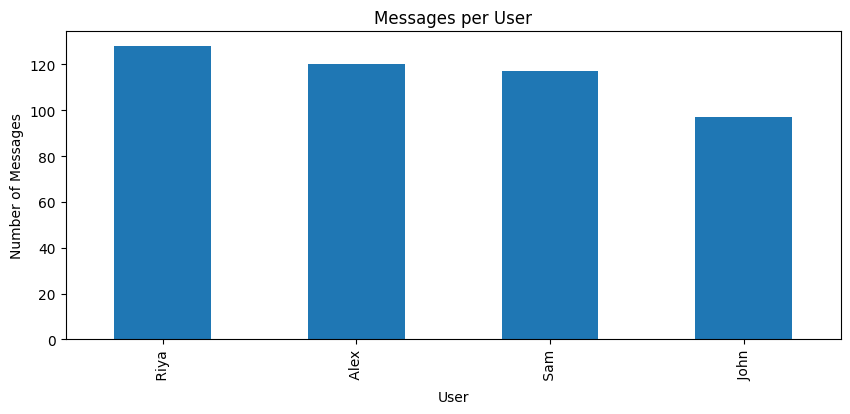

In [47]:
talkative_stats(df)

Most Active Day: 2024-02-02
Most Active Hour: 14.0:00


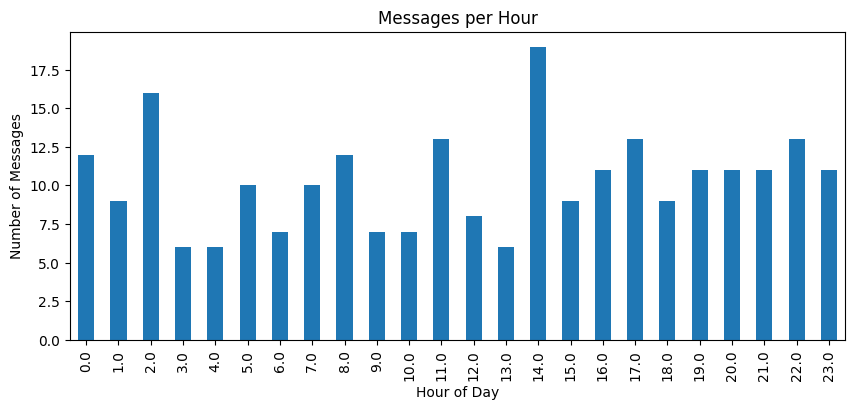

In [48]:
most_active_day_time(df)

Media messages sent by each person:
Name
Riya    26
Sam     19
Alex    17
John    16
Name: count, dtype: int64


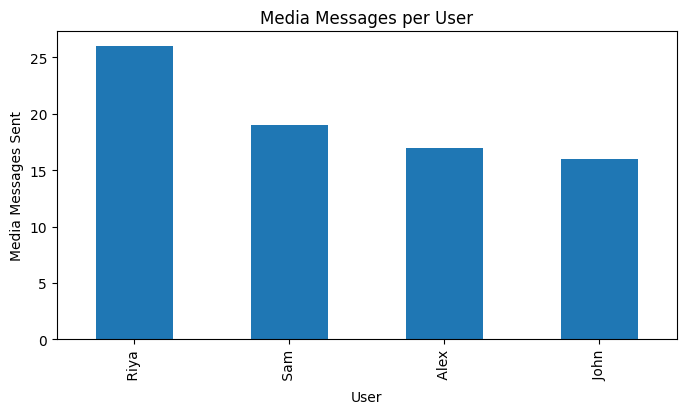

In [49]:
media_count_per_person(df)

All missed call messages:
           Date     Time   Name                          Chat
42   05/01/2024   01:29     Sam    Missed voice call from Sam
50   05/01/2024   16:04    Alex   Missed voice call from Alex
101  10/01/2024   08:44     Sam   Missed voice call from Alex
121  12/01/2024   13:51    Riya    Missed voice call from Sam
124  12/01/2024   21:16     Sam   Missed voice call from John
131  13/01/2024   13:15     Sam   Missed voice call from Alex
138  14/01/2024   00:46    Riya   Missed voice call from Riya
140  14/01/2024   06:38    Alex   Missed voice call from Alex
213  21/01/2024   02:13    John   Missed voice call from Riya
244  23/01/2024   10:21    John   Missed voice call from John
288  27/01/2024   08:31    Alex   Missed voice call from John
296  27/01/2024   22:02    John   Missed voice call from John
304  28/01/2024   12:25    Riya   Missed voice call from Alex
351  01/02/2024   20:57     Sam    Missed voice call from Sam
353  02/02/2024   02:46     Sam   Missed voi

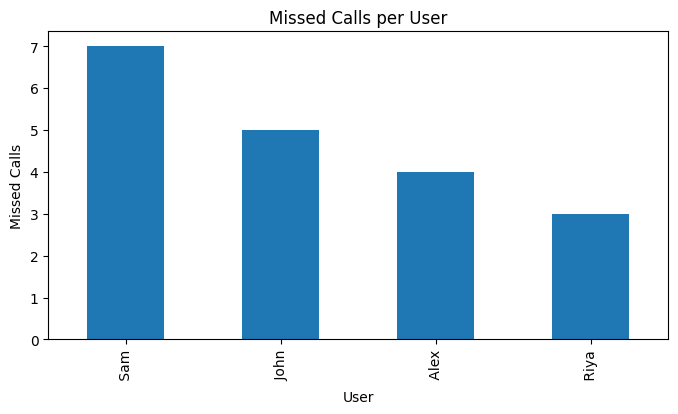

In [50]:
missed_call_stats(df)

## 6. Saving Model for Django


In [51]:
import joblib
joblib.dump(chosen_model, 'flirt_model.pkl')
joblib.dump(chosen_vectorizer, 'flirt_vectorizer.pkl')

['flirt_vectorizer.pkl']